In [4]:
import os,sys
import matplotlib.pylab as plt
import pickle
import glob
import numpy as np
import matplotlib as mpl
import pandas as pd
mpl.style.use('default')
mpl.style.use('default')

plt.rcParams.update({
    'font.family': 'sans-serif',
	'font.sans-serif': 'Arial',
	'font.family': 'Arial',

    # Base font size (set so text is ~7–8 pt at final print size)
    'font.size': 8,                  # main text (labels, ticks, legend)
    'axes.labelsize': 9,             # axis labels (x/y)
    'axes.titlesize': 10,            # panel titles / figure titles
    'figure.titlesize':11,
    'xtick.labelsize': 8,            # x-tick labels
    'ytick.labelsize': 8,            # y-tick labels
    'legend.fontsize': 8,            # legend text
    'legend.title_fontsize': 9,      # legend title (if used)

    # Lines and elements for clarity
    'lines.linewidth': 1.2,          # data lines
    'axes.linewidth': 1.0,           # axis spines
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,

    # General figure appearance
    'figure.dpi': 80,               # high resolution for export
    'savefig.dpi': 300,              # when using plt.savefig()
    'figure.figsize': (6.5, 4.5),    # example starting size (adjust to your needs; e.g., ~17 cm wide for full page)
    # 'figure.constrained_layout.use': True,
    'savefig.transparent': True,
    'pdf.fonttype':42,
	'ps.fonttype':42,
})
import pickle
sys.path.append(os.path.expanduser("~/Projects/Github/PyComplexHeatmap"))
import PyComplexHeatmap as pch
# print(PyComplexHeatmap.__version__)

In [5]:
df = pd.DataFrame(['AAAA1'] * 5 + ['BBBBB2'] * 5, columns=['AB'])
df['CD'] = ['C'] * 3 + ['D'] * 3 + ['G'] * 4
df['F'] = np.random.normal(0, 1, 10)
df.index = ['sample' + str(i) for i in range(1, df.shape[0] + 1)]
df_box = pd.DataFrame(np.random.randn(10, 4), columns=['Gene' + str(i) for i in range(1, 5)])
df_box.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['TMB1', 'TMB2'])
df_bar.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_scatter = pd.DataFrame(np.random.uniform(0, 10, 10), columns=['Scatter'])
df_scatter.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar1 = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['T1-A', 'T1-B'])
df_bar1.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar2 = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['T2-A', 'T2-B'])
df_bar2.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar3 = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['T3-A', 'T3-B'])
df_bar3.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar3.iloc[5,0]=np.nan
df_bar4 = pd.DataFrame(np.random.uniform(0, 10, (10, 1)), columns=['T4'])
df_bar4.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar4.iloc[7,0]=np.nan
print(df)
print(df_box.head())
print(df_scatter)
print(df_bar)
print(df_bar1)
print(df_bar2)
print(df_bar3)
print(df_bar4)

              AB CD         F
sample1    AAAA1  C  0.930188
sample2    AAAA1  C -0.093925
sample3    AAAA1  C -0.368558
sample4    AAAA1  D -0.868557
sample5    AAAA1  D -1.364857
sample6   BBBBB2  D -0.259479
sample7   BBBBB2  G -0.460343
sample8   BBBBB2  G -0.296751
sample9   BBBBB2  G -1.027369
sample10  BBBBB2  G -0.443103
            Gene1     Gene2     Gene3     Gene4
sample1 -0.441150 -0.685767 -0.211560  0.601082
sample2  0.478157 -0.860439 -1.689526 -2.882375
sample3  1.454780  0.163140  0.740371 -0.485751
sample4 -1.235108 -0.305013 -1.429477  1.684756
sample5  0.048505  0.519899  2.527911 -0.452874
           Scatter
sample1   8.393122
sample2   8.809044
sample3   8.932724
sample4   4.068440
sample5   7.667705
sample6   9.119778
sample7   6.051524
sample8   5.824975
sample9   0.452278
sample10  6.203144
              TMB1      TMB2
sample1   5.794572  4.782071
sample2   2.212025  4.764942
sample3   3.183444  0.451220
sample4   6.845737  5.998645
sample5   9.818383  1.573191

Plotting HeatmapAnnotations
Incresing ncol


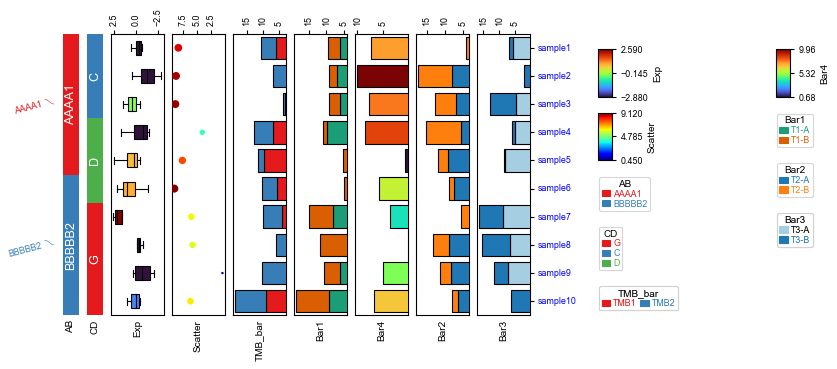

In [13]:
plt.figure(figsize=(8, 4))
row_ha = pch.HeatmapAnnotation(
            label=pch.anno_label(df.AB, merge=True,rotation=15),
            AB=pch.anno_simple(df.AB,add_text=True,legend=True,
                           #text_kws=dict(bbox={"pad":0},va='center',ha='center',rotation_mode='anchor')
                          ),
            CD=pch.anno_simple(df.CD,add_text=True,legend=True),
            Exp=pch.anno_boxplot(df_box, cmap='turbo',legend=True),
            Scatter=pch.anno_scatterplot(df_scatter), 
            TMB_bar=pch.anno_barplot(df_bar,legend=True,cmap='Set1'),
            Bar1=pch.anno_barplot(df_bar1,legend=True,cmap='Dark2'),
            Bar4=pch.anno_barplot(df_bar4,legend=True,cmap='turbo'),
            Bar2=pch.anno_barplot(df_bar2,legend=True,cmap='tab10'),
            Bar3=pch.anno_barplot(df_bar3,legend=True,cmap='Paired'),
            plot=True,legend=True,
            legend_order=['Exp','Scatter','AB','CD','TMB_bar','Bar4','Bar1','Bar2','Bar3'],
            legend_vgap=5,legend_hgap=30,
            axis=0,legend_hpad=20,label_side='bottom',wgap=3,
            )
row_ha.show_ticklabels(df.index.tolist(),fontdict={'color':'blue'},rotation=0)
plt.show()